### Python Data Cleaning

In [16]:
!pip install missingno


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [114]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import missingno as msno

In [115]:
#df =pd.read_csv('your_file.csv')
# For CSV files
#df =pd.read_excel('your_file.xlsx') # For Excel files
#df =pd.read_json('your_file.json') # For JSON files

In [116]:
data=pd.read_excel("messy_dataset.xlsx")
data

,Customer Name,Cust_id,date,Payment_method,quantity,Unit_price,amount,Product_Category,City,State,Discount,Order_Status,Salesperson,Customer_Email,Unnecessary_column
0,Charlie,C244,07-05-2024,Cash,NaN,50000.0,0.0,Grocery,Thane,Maharashtra,0.0,Delivered,Rahul,a@gmail.com,remove_me
1,Ivy,C219,22-03-2024,cc,1.0,99.5,99.5,Clothing,Nashik,Maharashtra,0.0,Delivered,Karan,user@outlook.com,remove_me
2,Grace,C013,30-08-2023,cash,NaN,499.0,0.0,Grocery,Pune,Gujarat,15.0,returned,Sneha,test@yahoo.com,remove_me
3,David,C234,30-09-2024,UPI,2.0,99.5,199.0,Grocery,Pune,Maharashtra,10.0,Cancelled,Sneha,user@outlook.com,remove_me
4,Frank,C120,09-12-2023,cash,2.0,99.5,199.0,Grocery,Nagpur,Gujarat,0.0,returned,Rahul,user@outlook.com,remove_me
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,David,C191,13-11-2024,cash,1.0,499.0,499.0,Electronics,Thane,Maharashtra,0.0,Cancelled,Amit,a@gmail.com,remove_me
1006,David,C079,07-07-2024,cash,NaN,499.0,0.0,Furniture,Thane,Gujarat,10.0,Returned,Priya,NaN,remove_me
1007,Ivy,C048,19-05-2024,Credit Card,5.0,499.0,2495.0,Furniture,Pune,Gujarat,0.0,Cancelled,Priya,NaN,remove_me
1008,Frank,C163,11-06-2025,NaN,2.0,499.0,999999.0,Electronics,Mumbai,Gujarat,5.0,Pending,Sneha,NaN,remove_me


In [117]:
#df.info() # Show column. n, non-null count & data.type
#df.describe() # Summary statistics for numerical columns
#df.head() # Displays the first 5 rows of the dataset
#df.shape # Shows the number of (rows, cols)
#df.columns # Lists all column names

### Checking the dataset

In [118]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer Name       1010 non-null   object 
 1   Cust_id             975 non-null    object 
 2   date                972 non-null    object 
 3   Payment_method      834 non-null    object 
 4   quantity            813 non-null    float64
 5   Unit_price          863 non-null    float64
 6   amount              1010 non-null   float64
 7   Product_Category    1010 non-null   object 
 8   City                1010 non-null   object 
 9   State               1010 non-null   object 
 10  Discount            822 non-null    float64
 11  Order_Status        1010 non-null   object 
 12  Salesperson         1010 non-null   object 
 13  Customer_Email      614 non-null    object 
 14  Unnecessary_column  1010 non-null   object 
dtypes: float64(4), object(11)
memory usage: 118.5+ KB


In [119]:
data.describe()

,quantity,Unit_price,amount,Discount
count,813.000000,863.000000,1010.000000,822.000000
mean,2.654367,10296.104287,41590.672277,7.475669
std,1.499539,19750.827188,153469.134075,5.631499
min,1.000000,99.500000,0.000000,0.000000
25%,1.000000,250.000000,0.000000,0.000000
50%,2.000000,499.000000,499.000000,5.000000
75%,3.000000,999.000000,2495.000000,15.000000
max,5.000000,50000.000000,999999.000000,15.000000


In [120]:
data.shape

(1010, 15)

In [121]:
data.columns

Index(['Customer Name', 'Cust_id', 'date', 'Payment_method', 'quantity',
       'Unit_price', 'amount', 'Product_Category', 'City', 'State', 'Discount',
       'Order_Status', 'Salesperson', 'Customer_Email', 'Unnecessary_column'],
      dtype='object')

In [122]:
data.head()

,Customer Name,Cust_id,date,Payment_method,quantity,Unit_price,amount,Product_Category,City,State,Discount,Order_Status,Salesperson,Customer_Email,Unnecessary_column
0,Charlie,C244,07-05-2024,Cash,NaN,50000.0,0.0,Grocery,Thane,Maharashtra,0.0,Delivered,Rahul,a@gmail.com,remove_me
1,Ivy,C219,22-03-2024,cc,1.0,99.5,99.5,Clothing,Nashik,Maharashtra,0.0,Delivered,Karan,user@outlook.com,remove_me
2,Grace,C013,30-08-2023,cash,NaN,499.0,0.0,Grocery,Pune,Gujarat,15.0,returned,Sneha,test@yahoo.com,remove_me
3,David,C234,30-09-2024,UPI,2.0,99.5,199.0,Grocery,Pune,Maharashtra,10.0,Cancelled,Sneha,user@outlook.com,remove_me
4,Frank,C120,09-12-2023,cash,2.0,99.5,199.0,Grocery,Nagpur,Gujarat,0.0,returned,Rahul,user@outlook.com,remove_me


### Check Missing Values (Numerically + Visually)

In [123]:
data.isnull().sum()

Customer Name           0
Cust_id                35
date                   38
Payment_method        176
quantity              197
Unit_price            147
amount                  0
Product_Category        0
City                    0
State                   0
Discount              188
Order_Status            0
Salesperson             0
Customer_Email        396
Unnecessary_column      0
dtype: int64

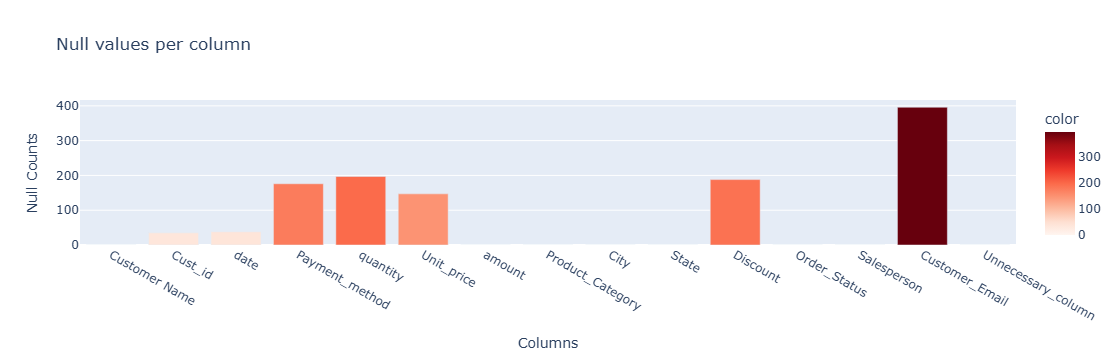

In [124]:
null_counts = data.isnull().sum()
# Create Plotly bar chart
fig = px.bar(
    x=null_counts.index, 
    y=null_counts.values,
    labels={'x':'Columns', 'y':'Null Counts'},
    title="Null values per column",
    color=null_counts.values,  # optional: color by count
    color_continuous_scale="Reds"
)
# Show chart
fig.show()

In [125]:
data.drop("Unnecessary_column",axis=1)
data

,Customer Name,Cust_id,date,Payment_method,quantity,Unit_price,amount,Product_Category,City,State,Discount,Order_Status,Salesperson,Customer_Email,Unnecessary_column
0,Charlie,C244,07-05-2024,Cash,NaN,50000.0,0.0,Grocery,Thane,Maharashtra,0.0,Delivered,Rahul,a@gmail.com,remove_me
1,Ivy,C219,22-03-2024,cc,1.0,99.5,99.5,Clothing,Nashik,Maharashtra,0.0,Delivered,Karan,user@outlook.com,remove_me
2,Grace,C013,30-08-2023,cash,NaN,499.0,0.0,Grocery,Pune,Gujarat,15.0,returned,Sneha,test@yahoo.com,remove_me
3,David,C234,30-09-2024,UPI,2.0,99.5,199.0,Grocery,Pune,Maharashtra,10.0,Cancelled,Sneha,user@outlook.com,remove_me
4,Frank,C120,09-12-2023,cash,2.0,99.5,199.0,Grocery,Nagpur,Gujarat,0.0,returned,Rahul,user@outlook.com,remove_me
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,David,C191,13-11-2024,cash,1.0,499.0,499.0,Electronics,Thane,Maharashtra,0.0,Cancelled,Amit,a@gmail.com,remove_me
1006,David,C079,07-07-2024,cash,NaN,499.0,0.0,Furniture,Thane,Gujarat,10.0,Returned,Priya,NaN,remove_me
1007,Ivy,C048,19-05-2024,Credit Card,5.0,499.0,2495.0,Furniture,Pune,Gujarat,0.0,Cancelled,Priya,NaN,remove_me
1008,Frank,C163,11-06-2025,NaN,2.0,499.0,999999.0,Electronics,Mumbai,Gujarat,5.0,Pending,Sneha,NaN,remove_me


### Handle Missing Values

In [126]:
# Identify column types
num_cols = data.select_dtypes(include=np.number).columns
cat_cols = data.select_dtypes(exclude=np.number).columns

In [127]:
# Numeric columns → mean imputation
for col in num_cols:
    data[col] = data[col].fillna(data[col].mean())

In [128]:
# Categorical columns → mode imputation
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

Customer Name         0
Cust_id               0
date                  0
Payment_method        0
quantity              0
Unit_price            0
amount                0
Product_Category      0
City                  0
State                 0
Discount              0
Order_Status          0
Salesperson           0
Customer_Email        0
Unnecessary_column    0
dtype: int64


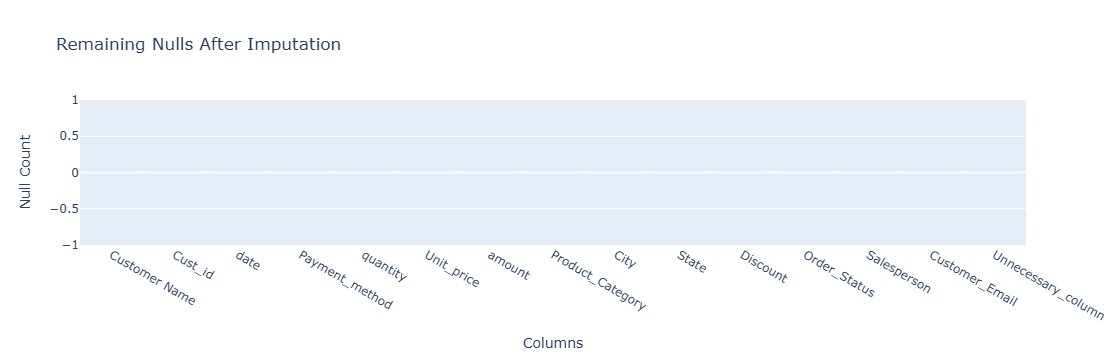

In [129]:
print(data.isnull().sum())
fig = px.bar(x=data.isnull().sum().index, y=data.isnull().sum().values,
             title="Remaining Nulls After Imputation", labels={'x':'Columns','y':'Null Count'})
fig.update_traces(marker_color='green')
fig.show()

### Rename Columns for Consistency

In [130]:
data.rename(columns={'Cust_id':'Customer_id'},inplace=True)
data.rename(columns={'date':'Date'},inplace=True)
data.rename(columns={'Cust_id':'Customer_id'},inplace=True)
data.rename(columns={'quantity':'Quantity'},inplace=True)
data.rename(columns={'amount':'Amount'},inplace=True)

In [131]:
data

,Customer Name,Customer_id,Date,Payment_method,Quantity,Unit_price,Amount,Product_Category,City,State,Discount,Order_Status,Salesperson,Customer_Email,Unnecessary_column
0,Charlie,C244,07-05-2024,Cash,2.654367,50000.0,0.0,Grocery,Thane,Maharashtra,0.0,Delivered,Rahul,a@gmail.com,remove_me
1,Ivy,C219,22-03-2024,cc,1.000000,99.5,99.5,Clothing,Nashik,Maharashtra,0.0,Delivered,Karan,user@outlook.com,remove_me
2,Grace,C013,30-08-2023,cash,2.654367,499.0,0.0,Grocery,Pune,Gujarat,15.0,returned,Sneha,test@yahoo.com,remove_me
3,David,C234,30-09-2024,UPI,2.000000,99.5,199.0,Grocery,Pune,Maharashtra,10.0,Cancelled,Sneha,user@outlook.com,remove_me
4,Frank,C120,09-12-2023,cash,2.000000,99.5,199.0,Grocery,Nagpur,Gujarat,0.0,returned,Rahul,user@outlook.com,remove_me
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,David,C191,13-11-2024,cash,1.000000,499.0,499.0,Electronics,Thane,Maharashtra,0.0,Cancelled,Amit,a@gmail.com,remove_me
1006,David,C079,07-07-2024,cash,2.654367,499.0,0.0,Furniture,Thane,Gujarat,10.0,Returned,Priya,user@outlook.com,remove_me
1007,Ivy,C048,19-05-2024,Credit Card,5.000000,499.0,2495.0,Furniture,Pune,Gujarat,0.0,Cancelled,Priya,user@outlook.com,remove_me
1008,Frank,C163,11-06-2025,Cash,2.000000,499.0,999999.0,Electronics,Mumbai,Gujarat,5.0,Pending,Sneha,user@outlook.com,remove_me


### Removing Outliers

In [132]:
Q1=data['Amount'].quantile(0.25)
Q3=data['Amount'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['Amount'] >=Q1-1.5*IQR) & (data['Amount']<=Q3+1.5* IQR)]

In [133]:
# List of columns to convert
cols_to_convert = ['Quantity', 'Discount', 'Amount', 'Unit_price']

# Convert each column to integer (round first if needed)
for col in cols_to_convert:
    data[col] = data[col].round().astype(int)


C:\Users\ganesh r. gawde\AppData\Local\Temp\ipykernel_29356\2476270593.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ganesh r. gawde\AppData\Local\Temp\ipykernel_29356\2476270593.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ganesh r. gawde\AppData\Local\Temp\ipykernel_29356\2476270593.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

In [134]:
data

,Customer Name,Customer_id,Date,Payment_method,Quantity,Unit_price,Amount,Product_Category,City,State,Discount,Order_Status,Salesperson,Customer_Email,Unnecessary_column
0,Charlie,C244,07-05-2024,Cash,3,50000,0,Grocery,Thane,Maharashtra,0,Delivered,Rahul,a@gmail.com,remove_me
1,Ivy,C219,22-03-2024,cc,1,100,100,Clothing,Nashik,Maharashtra,0,Delivered,Karan,user@outlook.com,remove_me
2,Grace,C013,30-08-2023,cash,3,499,0,Grocery,Pune,Gujarat,15,returned,Sneha,test@yahoo.com,remove_me
3,David,C234,30-09-2024,UPI,2,100,199,Grocery,Pune,Maharashtra,10,Cancelled,Sneha,user@outlook.com,remove_me
4,Frank,C120,09-12-2023,cash,2,100,199,Grocery,Nagpur,Gujarat,0,returned,Rahul,user@outlook.com,remove_me
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,David,C234,30-09-2024,UPI,2,100,199,Grocery,Pune,Maharashtra,10,Cancelled,Sneha,user@outlook.com,remove_me
1004,Frank,C120,09-12-2023,cash,2,100,199,Grocery,Nagpur,Gujarat,0,returned,Rahul,user@outlook.com,remove_me
1005,David,C191,13-11-2024,cash,1,499,499,Electronics,Thane,Maharashtra,0,Cancelled,Amit,a@gmail.com,remove_me
1006,David,C079,07-07-2024,cash,3,499,0,Furniture,Thane,Gujarat,10,Returned,Priya,user@outlook.com,remove_me


In [135]:
# Calculate total price
data['Total_Price'] = ((data['Quantity'] * data['Unit_price']) + data['Amount']) * (1 - data['Discount']/100)
data['Total_Price'] = data['Total_Price'].round().astype(int)
data

C:\Users\ganesh r. gawde\AppData\Local\Temp\ipykernel_29356\1654634231.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\ganesh r. gawde\AppData\Local\Temp\ipykernel_29356\1654634231.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Customer Name,Customer_id,Date,Payment_method,Quantity,Unit_price,Amount,Product_Category,City,State,Discount,Order_Status,Salesperson,Customer_Email,Unnecessary_column,Total_Price
0,Charlie,C244,07-05-2024,Cash,3,50000,0,Grocery,Thane,Maharashtra,0,Delivered,Rahul,a@gmail.com,remove_me,150000
1,Ivy,C219,22-03-2024,cc,1,100,100,Clothing,Nashik,Maharashtra,0,Delivered,Karan,user@outlook.com,remove_me,200
2,Grace,C013,30-08-2023,cash,3,499,0,Grocery,Pune,Gujarat,15,returned,Sneha,test@yahoo.com,remove_me,1272
3,David,C234,30-09-2024,UPI,2,100,199,Grocery,Pune,Maharashtra,10,Cancelled,Sneha,user@outlook.com,remove_me,359
4,Frank,C120,09-12-2023,cash,2,100,199,Grocery,Nagpur,Gujarat,0,returned,Rahul,user@outlook.com,remove_me,399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,David,C234,30-09-2024,UPI,2,100,199,Grocery,Pune,Maharashtra,10,Cancelled,Sneha,user@outlook.com,remove_me,359
1004,Frank,C120,09-12-2023,cash,2,100,199,Grocery,Nagpur,Gujarat,0,returned,Rahul,user@outlook.com,remove_me,399
1005,David,C191,13-11-2024,cash,1,499,499,Electronics,Thane,Maharashtra,0,Cancelled,Amit,a@gmail.com,remove_me,998
1006,David,C079,07-07-2024,cash,3,499,0,Furniture,Thane,Gujarat,10,Returned,Priya,user@outlook.com,remove_me,1347


In [136]:
data.drop("Unnecessary_column",axis=1)

,Customer Name,Customer_id,Date,Payment_method,Quantity,Unit_price,Amount,Product_Category,City,State,Discount,Order_Status,Salesperson,Customer_Email,Total_Price
0,Charlie,C244,07-05-2024,Cash,3,50000,0,Grocery,Thane,Maharashtra,0,Delivered,Rahul,a@gmail.com,150000
1,Ivy,C219,22-03-2024,cc,1,100,100,Clothing,Nashik,Maharashtra,0,Delivered,Karan,user@outlook.com,200
2,Grace,C013,30-08-2023,cash,3,499,0,Grocery,Pune,Gujarat,15,returned,Sneha,test@yahoo.com,1272
3,David,C234,30-09-2024,UPI,2,100,199,Grocery,Pune,Maharashtra,10,Cancelled,Sneha,user@outlook.com,359
4,Frank,C120,09-12-2023,cash,2,100,199,Grocery,Nagpur,Gujarat,0,returned,Rahul,user@outlook.com,399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,David,C234,30-09-2024,UPI,2,100,199,Grocery,Pune,Maharashtra,10,Cancelled,Sneha,user@outlook.com,359
1004,Frank,C120,09-12-2023,cash,2,100,199,Grocery,Nagpur,Gujarat,0,returned,Rahul,user@outlook.com,399
1005,David,C191,13-11-2024,cash,1,499,499,Electronics,Thane,Maharashtra,0,Cancelled,Amit,a@gmail.com,998
1006,David,C079,07-07-2024,cash,3,499,0,Furniture,Thane,Gujarat,10,Returned,Priya,user@outlook.com,1347


In [139]:
data.to_csv('Python_cleaned_data.csv', index=False)
data.to_csv(r"C:\Users\ganesh r. gawde\Python_cleaned_data.csv", index=False)